# **Neuromorphic computing - LAB 02**
May-June 2026, "Machine learning in applications" course

*Prof. G. Urgese, V. Fra, B. Leto*

---
Explore LIF neuron model and train a feedforward SNN on the psMNIST dataset
---

## Environment set-up

### Install packages

In [1]:
%%capture
!pip install hyperopt
!pip install matplotlib
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install scipy
!pip install seaborn
!pip install snntorch
!pip install torch==1.12.1+cu113 torchvision==0.13.1+cu113 torchaudio==0.12.1 --extra-index-url https://download.pytorch.org/whl/cu113
!pip install tqdm

### Basic import

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle as pkl
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
import torch
from torch.utils.data import TensorDataset
from tqdm import tqdm

c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Custom utility functions

In [3]:
def create_directory(
    directory_path
    ):
    """
    Muller-Cleve, Simon F.; Istituto Italiano di Tecnologia - IIT; Event-driven perception in robotics - EDPR; Genova, Italy.
    """
    if os.path.exists(directory_path):
        return None
    else:
        try:
            os.makedirs(directory_path)
        except:
            # in case another machine created the path meanwhile! :(
            return None
        return directory_path


def train_validation_test_split(
    data,
    label,
    split=[70, 20, 10],
    seed=None,
    multiple=False,
    save_dataset=False,
    save_tensor=False,
    labels_type=None,
    labels_mapping=None,
    save_name=None,
    save_path=None
    ):
    """
    Creates train-validation-test splits using the sklearn train_test_split() twice.
    Can be used either to prepare "ready-to-use" splits or to create and store splits.

    If multiple splits are not needed and no saving option is set, the lists x_train, y_train, x_val, y_val, x_test, y_test are returned (without labels mapping).

    Function accepts lists, arrays, and tensor.
    Default split: [training: 70, validation: 20, test: 10]

    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    Muller-Cleve, Simon F.; Istituto Italiano di Tecnologia - IIT; Event-driven perception in robotics - EDPR; Genova, Italy.
    """

    if multiple:
        if (not save_dataset) & (not save_tensor):
            raise ValueError("Multiple train-val splits are created but no saving option is enabled.")

    if save_dataset | save_tensor:
        if (save_path == None) | (save_name == None):
            raise ValueError("Check a file name and a path are provided to save the datasets.")
        filename_prefix = save_path + save_name
        create_directory(save_path)

    # do some sanity checks first
    if len(split) != 3:
        raise ValueError(
            f"Split dimensions are wrong. Expected 3 but got {len(split)}. Please provide split in the form [train size, test size, validation size].")
    if min(split) == 0.0:
        raise ValueError(
            "Found entry 0.0. If you want to use only perfrom a two-folded split, use the sklearn train_test_split function only please.")
    if sum(split) > 99.0:
        split = [x/100 for x in split]
    if sum(split) < 0.99:
        raise ValueError("Please use a split summing up to 1, or 100%.")

    train, val, test = split
    split_1 = test
    split_2 = 1 - train/(train+val)

    x_trainval, x_test, y_trainval, y_test = train_test_split(
        data, label, test_size=split_1, shuffle=True, stratify=label, random_state=seed)


    if save_dataset: # Save the test split
        filename_test = filename_prefix + "_test"
        # xs test
        with open(f"{filename_test}.pkl", 'wb') as handle:
            pkl.dump(np.array(x_test, dtype=object), handle,
                        protocol=pkl.HIGHEST_PROTOCOL)
        # ys test
        with open(f"{filename_test}_label.pkl", 'wb') as handle:
            pkl.dump(np.array(y_test, dtype=object), handle,
                        protocol=pkl.HIGHEST_PROTOCOL)

    if save_tensor: # Save the test split
        filename_test = filename_prefix + "_ds_test"
        x_test = torch.as_tensor(np.array(x_test), dtype=torch.float)
        if labels_type == str:
            labels_test = torch.as_tensor(value2index(
                y_test, labels_mapping), dtype=torch.long)
        else:
            labels_test = torch.as_tensor(y_test, dtype=torch.long)
        ds_test = TensorDataset(x_test, labels_test)
        torch.save(ds_test, "{}.pt".format(filename_test))

    if multiple:

        for ii in range(10):

            x_train, x_val, y_train, y_val = train_test_split(
                x_trainval, y_trainval, test_size=split_2, shuffle=True, stratify=y_trainval, random_state=seed)

            if save_dataset:

                filename_train = filename_prefix + "_train"
                filename_val = filename_prefix + "_val"

                # xs training
                with open(f"{filename_train}_{ii}.pkl", 'wb') as handle:
                    pkl.dump(np.array(x_train, dtype=object), handle,
                                protocol=pkl.HIGHEST_PROTOCOL)
                # ys training
                with open(f"{filename_train}_{ii}_label.pkl", 'wb') as handle:
                    pkl.dump(np.array(y_train, dtype=object), handle,
                                protocol=pkl.HIGHEST_PROTOCOL)

                # xs validation
                with open(f"{filename_val}_{ii}.pkl", 'wb') as handle:
                    pkl.dump(np.array(x_val, dtype=object), handle,
                                protocol=pkl.HIGHEST_PROTOCOL)
                # ys validation
                with open(f"{filename_val}_{ii}_label.pkl", 'wb') as handle:
                    pkl.dump(np.array(y_val, dtype=object), handle,
                                protocol=pkl.HIGHEST_PROTOCOL)

            if save_tensor:

                filename_train = filename_prefix + "_ds_train"
                filename_val = filename_prefix + "_ds_val"

                x_train = torch.as_tensor(np.array(x_train), dtype=torch.float)
                if labels_type == str:
                    labels_train = torch.as_tensor(value2index(
                        y_train, labels_mapping), dtype=torch.long)
                else:
                    labels_train = torch.as_tensor(y_train, dtype=torch.long)

                x_validation = torch.as_tensor(
                    np.array(x_val), dtype=torch.float)
                if labels_type == str:
                    labels_validation = torch.as_tensor(value2index(
                        y_val, labels_mapping), dtype=torch.long)
                else:
                    labels_validation = torch.as_tensor(y_val, dtype=torch.long)

                ds_train = TensorDataset(x_train, labels_train)
                ds_val = TensorDataset(x_validation, labels_validation)

                torch.save(ds_train, "{}_{}.pt".format(filename_train,ii))
                torch.save(ds_val, "{}_{}.pt".format(filename_val,ii))

    else:

        x_train, x_val, y_train, y_val = train_test_split(
            x_trainval, y_trainval, test_size=split_2, shuffle=True, stratify=y_trainval, random_state=seed)

        if save_dataset:

            filename_train = filename_prefix + "_train"
            filename_val = filename_prefix + "_val"

            # xs training
            with open(f"{filename_train}.pkl", 'wb') as handle:
                pkl.dump(np.array(x_train, dtype=object), handle,
                            protocol=pkl.HIGHEST_PROTOCOL)
            # ys training
            with open(f"{filename_train}_label.pkl", 'wb') as handle:
                pkl.dump(np.array(y_train, dtype=object), handle,
                            protocol=pkl.HIGHEST_PROTOCOL)

            # xs validation
            with open(f"{filename_val}.pkl", 'wb') as handle:
                pkl.dump(np.array(x_val, dtype=object), handle,
                            protocol=pkl.HIGHEST_PROTOCOL)
            # ys validation
            with open(f"{filename_val}_label.pkl", 'wb') as handle:
                pkl.dump(np.array(y_val, dtype=object), handle,
                            protocol=pkl.HIGHEST_PROTOCOL)

        if save_tensor:

            filename_train = filename_prefix + "_ds_train"
            filename_val = filename_prefix + "_ds_val"

            x_train = torch.as_tensor(np.array(x_train), dtype=torch.float)
            if labels_type == str:
                labels_train = torch.as_tensor(value2index(
                    y_train, labels_mapping), dtype=torch.long)
            else:
                labels_train = torch.as_tensor(y_train, dtype=torch.long)

            x_validation = torch.as_tensor(
                np.array(x_val), dtype=torch.float)
            if labels_type == str:
                labels_validation = torch.as_tensor(value2index(
                    y_val, labels_mapping), dtype=torch.long)
            else:
                labels_validation = torch.as_tensor(y_val, dtype=torch.long)

            ds_train = TensorDataset(x_train, labels_train)
            ds_val = TensorDataset(x_validation, labels_validation)

            torch.save(ds_train, filename_train)
            torch.save(ds_val, filename_val)

        return x_train, y_train, x_val, y_val, x_test, y_test


def value2key(
    entry,
    dictionary
    ):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    if (type(entry) != list) & (type(entry) != np.ndarray):

        key = [list(dictionary.keys())[list(dictionary.values()).index(entry)]]

    else:

        key = [list(dictionary.keys())[list(dictionary.values()).index(e)] for e in entry]

    return key


def index2key(
    entry,
    dictionary
    ):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    if (type(entry) != list) & (type(entry) != np.ndarray):

        key = [list(dictionary.keys())[entry]]

    else:

        key = [list(dictionary.keys())[e] for e in entry]

    return key


def value2index(
    entry,
    dictionary
    ):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    if (type(entry) != list) & (type(entry) != np.ndarray):

        idx = [list(dictionary.values()).index(entry)]

    else:

        idx = [list(dictionary.values()).index(e) for e in entry]

    return idx


def index2value(
    entry,
    dictionary
    ):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    if (type(entry) != list) & (type(entry) != np.ndarray):

        value = [list(dictionary.values())[entry]]

    else:

        value = [list(dictionary.values())[e] for e in entry]

    return value


def training_loop(
    dataset,
    batch_size,
    net,
    optimizer,
    loss_fn,
    device):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    batch_loss = []
    batch_acc = []

    for data, labels in tqdm(train_loader):

      data = data#.to(device).swapaxes(1, 0)
      labels = labels#.to(device)

      net.train()
      spk_rec, _, _ = net(data)

      # Training loss
      loss_val = loss_fn(spk_rec, labels)
      batch_loss.append(loss_val.detach().cpu().item())

      # Training accuracy
      act_total_out = torch.sum(spk_rec, 0)  # sum over time
      _, neuron_max_act_total_out = torch.max(act_total_out, 1)  # argmax over output units to compare to labels
      batch_acc.append(np.mean((neuron_max_act_total_out == labels).detach().cpu().numpy()))

      # Gradient calculation + weight update
      optimizer.zero_grad()
      loss_val.backward()
      optimizer.step()

    epoch_loss = np.mean(batch_loss)
    epoch_acc = np.mean(batch_acc)

    return [epoch_loss, epoch_acc]


def val_test_loop(
    dataset,
    batch_size,
    net,
    loss_fn,
    device,
    shuffle=True,
    label_probabilities=False,
    return_spikes=False):
    """
    Fra, Vittorio; Politecnico di Torino; EDA Group; Torino, Italy.
    """

    with torch.no_grad():
      net.eval()

      loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)

      batch_loss = []
      batch_acc = []

      for data, labels in tqdm(loader):
          data = data#.to(device).swapaxes(1, 0)
          labels = labels#.to(device)

          spk_out, _, _ = net(data)

          # Loss
          loss_val = loss_fn(spk_out, labels)
          batch_loss.append(loss_val.detach().cpu().item())

          # Accuracy
          act_total_out = torch.sum(spk_out, 0)  # sum over time
          _, neuron_max_act_total_out = torch.max(act_total_out, 1)  # argmax over output units to compare to labels
          batch_acc.append(np.mean((neuron_max_act_total_out == labels).detach().cpu().numpy()))

      if label_probabilities:
          log_softmax_fn = nn.LogSoftmax(dim=-1)
          log_p_y = log_softmax_fn(act_total_out)
          if return_spikes:
            return [np.mean(batch_loss), np.mean(batch_acc)], torch.exp(log_p_y), spk_out.detach().cpu().numpy()
          else:
            return [np.mean(batch_loss), np.mean(batch_acc)], torch.exp(log_p_y)
      else:
        if return_spikes:
          return [np.mean(batch_loss), np.mean(batch_acc)], spk_out.detach().cpu().numpy()
        else:
          return [np.mean(batch_loss), np.mean(batch_acc)]

### General settings

In [4]:
use_seed = True

if use_seed:
    seed = 42
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
else:
    seed = None

In [5]:
device = "cuda:0"

## Import MNIST dataset

In [6]:
# Load MNIST dataset
(train_images, train_labels), \
  (test_images,test_labels) = tf.keras.datasets.mnist.load_data()

In [7]:
# Extract a random index from the training set
rnd_idx = np.random.randint(0,int(0.1*len(train_images)))
train_images[rnd_idx].flatten()

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0, 132, 255, 165, 114,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35, 224, 253,
       253, 253, 166,  97,  13,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

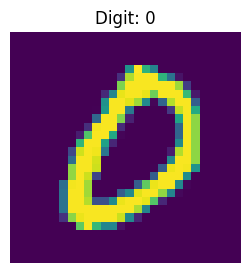

In [8]:
# Plot the random (original) example
plt.figure(figsize=(3,3))
plt.imshow(np.reshape(train_images[rnd_idx], (28, 28)))
plt.axis("off")
plt.title("Digit: {}".format(str(train_labels[rnd_idx])))
plt.show()

In [9]:
# Flatten images
train_images = train_images.reshape((train_images.shape[0], -1, 1))
test_images = test_images.reshape((test_images.shape[0], -1, 1))

In [10]:
# Apply permutation
perm = np.random.RandomState(seed).permutation(train_images.shape[1])
train_images = train_images[:, perm]
test_images = test_images[:, perm]

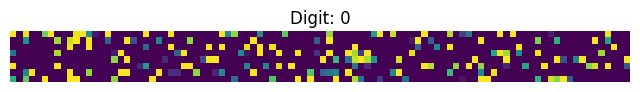

In [11]:
# Plot the SAME random (flat and permuted) example
plt.figure(figsize=(8,4.5))
plt.imshow(np.reshape(train_images[rnd_idx], (8, -1)))
plt.axis("off")
plt.title("Digit: {}".format(str(train_labels[rnd_idx])))
plt.show()

In [12]:
print("Original training set \t ---images---\n \ttype: {}\n \tshape:{}".format(
    type(train_images),train_images.shape))
print("Original training set \t ---labels---\n \ttype: {}\n \tshape:{}".format(
    type(train_labels),train_labels.shape))
print("\n")
print("Original test set \t ---images---\n \ttype: {}\n \tshape:{}".format(
    type(test_images),test_images.shape))
print("Original test set \t ---labels---\n \ttype: {}\n \tshape:{}".format(
    type(test_labels),test_labels.shape))

Original training set 	 ---images---
 	type: <class 'numpy.ndarray'>
 	shape:(60000, 784, 1)
Original training set 	 ---labels---
 	type: <class 'numpy.ndarray'>
 	shape:(60000,)


Original test set 	 ---images---
 	type: <class 'numpy.ndarray'>
 	shape:(10000, 784, 1)
Original test set 	 ---labels---
 	type: <class 'numpy.ndarray'>
 	shape:(10000,)


In [13]:
# Merge training and test to then prepare a different split
data_numpy = np.concatenate((train_images,test_images))
labels_numpy = np.concatenate((train_labels,test_labels))

# Normalize data: rescale into [0,1]
data_numpy = data_numpy/np.max(data_numpy)

data_numpy[rnd_idx].flatten()

array([0.99215686, 0.        , 0.96862745, 0.        , 0.        ,
       0.78039216, 0.99215686, 0.        , 0.        , 0.        ,
       0.96470588, 0.99215686, 0.50980392, 0.06666667, 0.        ,
       0.99215686, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.99215686, 0.        , 0.        , 0.        ,
       0.99215686, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.99215686, 0.45490196,
       0.83137255, 0.01176471, 0.        , 0.        , 0.4745098 ,
       0.        , 0.        , 0.        , 0.75294118, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.83529412, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.57254902, 0.99215686, 0.        ,
       0.92156863, 0.        , 0.        , 0.        , 0.        ,
       0.99215686, 0.        , 0.        , 0.        , 0.88627451,
       0.        , 0.20784314, 0.40392157, 0.        , 0.     

## snnTorch

In [14]:
import torch.nn as nn
from torch.utils.data import DataLoader

import snntorch as snn
from snntorch import functional as SF

### Prepare data

NOTE that we try to limit as much as possible the pre-processing of data, in order to use "raw" (although normalized) data only.

In [15]:
data = torch.tensor(data_numpy[:int(1.0*data_numpy.shape[0])], dtype=torch.float)
labels = torch.tensor(np.array(labels_numpy[:int(1.0*len(labels_numpy))]), dtype=torch.long)

num_steps = len(data[0])

x_train, y_train, x_val, y_val, x_test, y_test = train_validation_test_split(
  data,
  labels,
  split=[70, 20, 10],
  seed=42)

ds_train = TensorDataset(x_train.to(device), y_train.to(device))
ds_val = TensorDataset(x_val.to(device), y_val.to(device))
ds_test = TensorDataset(x_test.to(device), y_test.to(device))

### LIF neuron model

---
*from snnTorch Tutorial 2: https://snntorch.readthedocs.io/en/latest/tutorials/tutorial_2.html*

Somewhere in the middle between the Hodgkin-Huxley model and artificial neurons relying on activation functions fed with weighted input, lies the leaky integrate-and-fire (LIF) neuron model. It takes the sum of weighted inputs, much like the artificial neuron. But rather than passing it directly to an activation function, it will integrate the input over time with a leakage, much like an **RC circuit**. If the integrated value exceeds a threshold, then the LIF neuron will emit a voltage spike. The LIF neuron abstracts away the shape and profile of the output spike; it is simply treated as a discrete event. As a result, information is not stored within the spike, but rather the timing (or frequency) of spikes. Simple spiking neuron models have produced much insight into the neural code, memory, network dynamics, and more recently, deep learning. The LIF neuron sits in the sweet spot between biological plausibility and practicality.

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial2/2_1_neuronmodels.png?raw=true' width="1000">
</center>

Let's say some arbitrary time-varying current $I_{\rm in}(t)$ is injected into the neuron, be it via electrical stimulation or from other neurons. The total current in the circuit is conserved, so:

$$I_{\rm in}(t) = I_{R} + I_{C}$$

From Ohm's Law, the membrane potential measured between the inside and outside of the neuron $U_{\rm mem}$ is proportional to the current through the resistor:

$$I_{R}(t) = \frac{U_{\rm mem}(t)}{R}$$

The capacitance is a proportionality constant between the charge stored on the capacitor $Q$ and $U_{\rm mem}(t)$:


$$Q = CU_{\rm mem}(t)$$

The rate of change of charge gives the capacitive current:

$$\frac{dQ}{dt}=I_C(t) = C\frac{dU_{\rm mem}(t)}{dt}$$

Therefore:

$$I_{\rm in}(t) = \frac{U_{\rm mem}(t)}{R} + C\frac{dU_{\rm mem}(t)}{dt}$$

$$\implies RC \frac{dU_{\rm mem}(t)}{dt} = -U_{\rm mem}(t) + RI_{\rm in}(t)$$

The right hand side of the equation is of units **\[Voltage]**. On the left hand side of the equation, the term $\frac{dU_{\rm mem}(t)}{dt}$ is of units **\[Voltage/Time]**. To equate it to the left hand side (i.e., voltage), $RC$ must be of unit **\[Time]**. We refer to $\tau = RC$ as the time constant of the circuit:

$$ \tau \frac{dU_{\rm mem}(t)}{dt} = -U_{\rm mem}(t) + RI_{\rm in}(t)$$

The passive membrane is therefore described by a linear differential equation.

For a derivative of a function to be of the same form as the original function, i.e., $\frac{dU_{\rm mem}(t)}{dt} \propto U_{\rm mem}(t)$, this implies the solution is exponential with a time constant $\tau$.

Say the neuron starts at some value $U_{0}$ with no further input, i.e., $I_{\rm in}(t)=0$. The solution of the linear differential equation is:

$$U_{\rm mem}(t) = U_0e^{-\frac{t}{\tau}}$$

The general solution is shown below.

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial2/2_4_RCmembrane.png?raw=true' width="500">
</center>

---

In [16]:
################################################################################
##### DEFINE HERE THE LIF_neuron FUNCTION FOR A SINGLE LIF NEURON ##############
################################################################################

def LIF_neuron(input, threshold, beta):

    neu = snn.Leaky(threshold=threshold, beta=beta)

    mem = neu.init_leaky()
    spk_rec = []
    mem_rec = []
    x = input.to(device)
    for step in range(input.shape[0]):
        spk, mem = neu(x[step], mem.to('cuda:0'))
        spk_rec.append(spk.detach())
        mem_rec.append(mem.detach())

    return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)

In [17]:
################################################################################
##### SET DIFFERENT VALUES OF threshold_lif AND beta_lif TO INVESTIGATE HOW THEY
##### AFFECT THE SPIKING ACTIVITY OF A SINGLE LIF NEURON THROUGH THE PLOTS IN
##### THE FOLLOWING CELLS
################################################################################

threshold_lif = 100
beta_lif = 1

In [18]:
### Neuron activity

spk_digit, mem_digit = LIF_neuron(data[rnd_idx], threshold_lif, beta_lif)

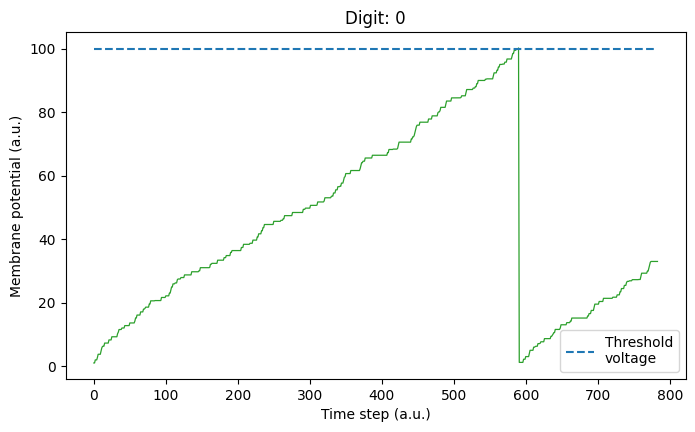

In [19]:
plt.figure(figsize=(8,4.5))
# MEMBRANE POTENTIAL
plt.plot(range(mem_digit.shape[0]),mem_digit.cpu().numpy(),
            color="tab:green", linewidth=0.9)
# THRESHOLD VOLATGE
plt.plot(range(mem_digit.shape[0]),np.ones(mem_digit.shape[0])*threshold_lif,
            "--", color="tab:blue", label="Threshold\nvoltage")
plt.xlabel("Time step (a.u.)")
plt.ylabel("Membrane potential (a.u.)")
plt.title("Digit: {}".format(labels[rnd_idx]))
plt.legend()
plt.show()

In [20]:
print("The membrane potential reached the threhsold voltage {} times.".format(
    np.sum([mem_digit.cpu().numpy() >= threshold_lif]))
)

The membrane potential reached the threhsold voltage 1 times.


In [21]:
spk_digit.flatten()

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 

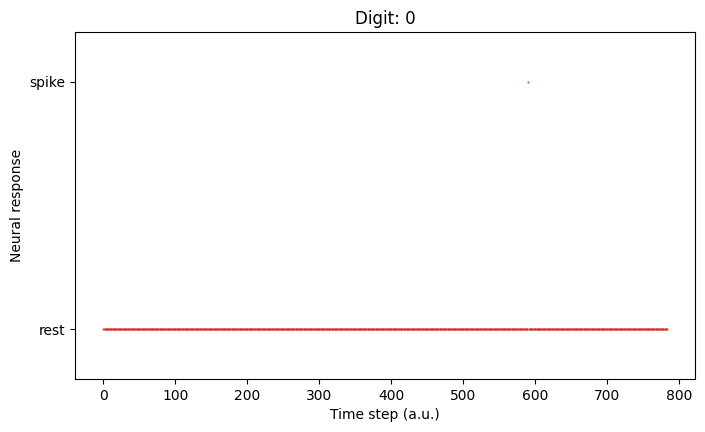

In [22]:
plt.figure(figsize=(8,4.5))
plt.scatter(range(spk_digit.shape[0]),spk_digit.cpu().numpy(),
            s=0.2, color="tab:red")
plt.xlabel("Time step (a.u.)")
plt.ylabel("Neural response")
plt.ylim((-0.2,1.2))
plt.yticks([0,1], ['rest', 'spike'])
plt.title("Digit: {}".format(labels[rnd_idx]))
plt.show()

In [23]:
print("Total number of spikes: {}".format(
  int(torch.sum(spk_digit)))
)

Total number of spikes: 1


### Feedforward SNN

In [24]:
################################################################################
##### SET SUITABLE VALUES FOR THE FOLLOWING PARAMETERS #########################
################################################################################

settings = {
  "enc_pop":    5,
  "nb_hidden":  500,
  "beta_enc":   0.9,    # range of values: [0, 1]
  "thr_enc":    0.8,    # range of possible values to try: [0.5, 2]
  "beta_hid":   0.8,    # range of values: [0, 1]
  "thr_hid":    0.8,    # range of possible values to try: [0.5, 2]
  "beta_out":   0.8,    # range of values: [0, 1]
  "thr_out":    0.5,    # range of possible values to try: [0.5, 2]
  "nb_epochs":  5,      # can be arbitrarily changed (typically, 100-500 is chosen when enough resources are available)
  "lr":         0.001, # possible values to try: [0.005, 0.002, 0.001, 0.0005, 0.00015]
  "batch_size": 128
}

In [25]:
### Network structure (input data --> encoding -> hidden -> output)
output_enc = int(settings["enc_pop"])
num_hidden = int(settings["nb_hidden"])
num_outputs = 10

class Net(nn.Module):
  def __init__(self):
    super().__init__()

    ##### Initialize layers #####
    ### Encoding layer
    self.enc = nn.Linear(1, output_enc)
    self.s_enc = snn.Leaky(beta=settings["beta_enc"], threshold=settings["thr_enc"], learn_threshold=True)
    ### Hidden layer
    self.fc1 = nn.Linear(output_enc, num_hidden)
    self.s1 = snn.Synaptic(alpha=settings["beta_hid"], beta=settings["beta_hid"], threshold=settings["thr_hid"], learn_threshold=True)
    ### Output layer
    self.fc2 = nn.Linear(num_hidden, num_outputs)
    self.s2 = snn.Synaptic(alpha=settings["beta_out"], beta=settings["beta_out"], threshold=settings["thr_out"], learn_threshold=True)

  def forward(self, x):

    ##### Initialize hidden states at t=0 #####
    ### Encoding layer
    mem_enc = self.s_enc.init_leaky()
    ### Hidden layer
    syn1, mem1 = self.s1.init_synaptic()
    ### Output layer
    syn2, mem2 = self.s2.init_synaptic()

    # Record the final layer
    spk2_rec = []
    mem2_rec = []

    for step in range(num_steps):
      ### Encoding layer
      cur_enc = self.enc(x[:,step])
      spk_enc, mem_enc = self.s_enc(cur_enc, mem_enc)
      ### Hidden layer
      cur1 = self.fc1(spk_enc)
      spk1, syn1, mem1 = self.s1(cur1, syn1, mem1)
      ### Output layer
      cur2 = self.fc2(spk1)
      spk2, syn2, mem2 = self.s2(cur2, syn2, mem2)

      spk2_rec.append(spk2)
      mem2_rec.append(mem2)

    return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0), torch.stack(mem2_rec, dim=0)

net = Net().to(device)


In [26]:
### Set the loss function
loss_fn = SF.ce_count_loss()

### Set the optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=settings["lr"], betas=(0.9, 0.999))

### Set the batch size
batch_size = settings["batch_size"]

#### Training (with validation)

In [27]:
num_epochs = settings["nb_epochs"]

training_results = []
validation_results = []

for epoch in range(num_epochs):

  train_loss, train_acc = training_loop(ds_train, batch_size, net, optimizer, loss_fn, device)
  val_loss, val_acc = val_test_loop(ds_val, batch_size, net, loss_fn, device)

  training_results.append([train_loss, train_acc])
  validation_results.append([val_loss, val_acc])

  print("Epoch {}/{}: \n\ttraining loss: {} \n\tvalidation loss: {} \n\ttraining accuracy: {}% \n\tvalidation accuracy: {}%".format(epoch+1, num_epochs, training_results[-1][0], validation_results[-1][0], np.round(training_results[-1][1]*100,4), np.round(validation_results[-1][1]*100,4)))

100%|██████████| 110/110 [06:18<00:00,  3.44s/it]


Epoch 1/5: 
	training loss: 4.914884582823313 
	validation loss: 2.2846799048510467 
	training accuracy: 9.9075% 
	validation accuracy: 9.8556%


100%|██████████| 110/110 [04:40<00:00,  2.55s/it]


Epoch 2/5: 
	training loss: 2.2673596943638654 
	validation loss: 2.242012240669944 
	training accuracy: 12.6029% 
	validation accuracy: 16.411%


100%|██████████| 110/110 [04:05<00:00,  2.23s/it]


Epoch 3/5: 
	training loss: 2.241493327810621 
	validation loss: 2.211362045461481 
	training accuracy: 16.2181% 
	validation accuracy: 17.1141%


100%|██████████| 110/110 [04:19<00:00,  2.36s/it]


Epoch 4/5: 
	training loss: 2.22928575062565 
	validation loss: 2.2073982628909024 
	training accuracy: 17.0389% 
	validation accuracy: 18.2268%


 70%|███████   | 77/110 [05:07<02:11,  3.99s/it]


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (5,) and (4,)

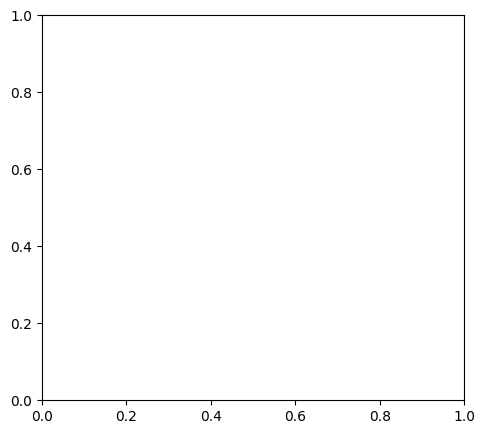

In [28]:
################################################################################
##### PLOT THE TRAINING AND VALIDATION CURVES FOR BOTH LOSS AND ACCURACY #######
################################################################################
training_results = np.array(training_results)
validation_results = np.array(validation_results)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(num_epochs), training_results[:,0], label="training loss", color="tab:blue")
plt.plot(range(num_epochs), validation_results[:,0], label="validation loss", color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(num_epochs), training_results[:,1], label="training accuracy", color="tab:blue")
plt.plot(range(num_epochs), validation_results[:,1], label="validation accuracy", color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.show()

#### Test

In [ ]:
test_results, lbl_probs, spk_out = val_test_loop(ds_test, batch_size, net, loss_fn, device, label_probabilities=True, return_spikes=True)

print("Test accuracy: {}%".format(np.round(test_results[1]*100,4)))

100%|██████████| 6/6 [00:13<00:00,  2.28s/it]

Test accuracy: 15.7812%


#### Single-sample inference

In [ ]:
single_sample = next(iter(DataLoader(ds_test, batch_size=1, shuffle=True)))
print("Randomly selected sample: {}".format(single_sample[1].cpu()[0]))

Randomly selected sample: 1


100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


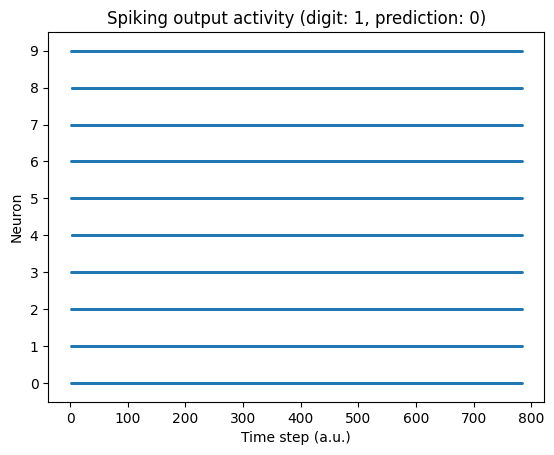

In [ ]:
### Inference
_, lbl_probs, spk_out = val_test_loop(TensorDataset(single_sample[0],single_sample[1]), 1, net, loss_fn, device, label_probabilities=True, return_spikes=True)

### Plot output spiking activity
spk_out = np.moveaxis(spk_out,1,2)
spk_out = np.squeeze(spk_out, axis=-1)
spk_out.shape
aer = []
for num,el in enumerate(spk_out):
  addr = np.where(el)[0].tolist()
  if len(addr) > 0:
    for ii in addr:
      aer.append([num,ii])
aer = np.array(aer)
plt.scatter(aer[:,0], aer[:,1], s=1)
plt.xlabel("Time step (a.u.)")
plt.ylabel("Neuron")
plt.title("Spiking output activity (digit: {}, prediction: {})".format(single_sample[1].cpu()[0],np.argmax(lbl_probs.cpu())))
plt.ylim(-0.5,9.5)
plt.yticks(range(10))
plt.show()
